# Conditioning of the SHT

This notebook investigates the conditioning of the spherical harmonic transform (SHT)
by constructing the Vandermonde matrix $S$ and analyzing its Gramian $G = S^T \mathrm{diag}(\omega)\, S$.

A well-conditioned SHT means that the analysis (forward) and synthesis (inverse) steps
are numerically stable. We verify this by checking that the condition number of the
Gramian is close to 1 and that the round-trip $\mathrm{ISHT}(\mathrm{SHT}(u)) \approx u$
reproduces the input.

## Setup

In [1]:
import numpy as np
import torch

from torch_harmonics.quadrature import legendre_gauss_weights, clenshaw_curtiss_weights
from torch_harmonics import RealSHT, InverseRealSHT

import matplotlib.pyplot as plt

from torch_harmonics.plotting import plot_sphere

In [2]:
nlat = 32
nlon = 2*nlat
grid = "legendre-gauss"

# for quadrature and plotting
if grid == "legendre-gauss":
    lmax = mmax = nlat
    xq, wq = legendre_gauss_weights(nlat)
elif grid =="equiangular":
    lmax = mmax = nlat//2-1
    xq, wq = clenshaw_curtiss_weights(nlat)

sht = RealSHT(nlat, nlon, lmax=lmax, mmax=mmax, grid=grid)
isht = InverseRealSHT(nlat, nlon, lmax=lmax, mmax=mmax, grid=grid)

lat = torch.arccos(xq)
omega = torch.pi * wq.float() / nlat
omega = omega.reshape(-1, 1).repeat(1, nlon)

omega.sum()

tensor(12.5664)

## Constructing the Vandermonde matrix

The Vandermonde matrix $S$ encodes the action of the inverse SHT: $u = S\,\theta$,
where $\theta$ are the spectral coefficients and $u$ the grid values.
We construct it column by column, applying the ISHT to each unit basis vector $e_{l,m}$
in spectral space.

In [3]:
# forming the Vandermonde matrix
nmodes = int(lmax * (lmax+1) / 2)
e = torch.zeros(nmodes, lmax, mmax, dtype=torch.complex64)

midx = lambda l,m : l*(l+1)//2 + m

for l in range(lmax):
    for m in range(l+1):
        e[midx(l,m), l, m] = 1.0

vdm = isht(e) # nmodes x nlat x nlon

Each column of the Vandermonde matrix corresponds to a spherical harmonic $Y_l^m$.
Let us visualize the first few to verify the construction:

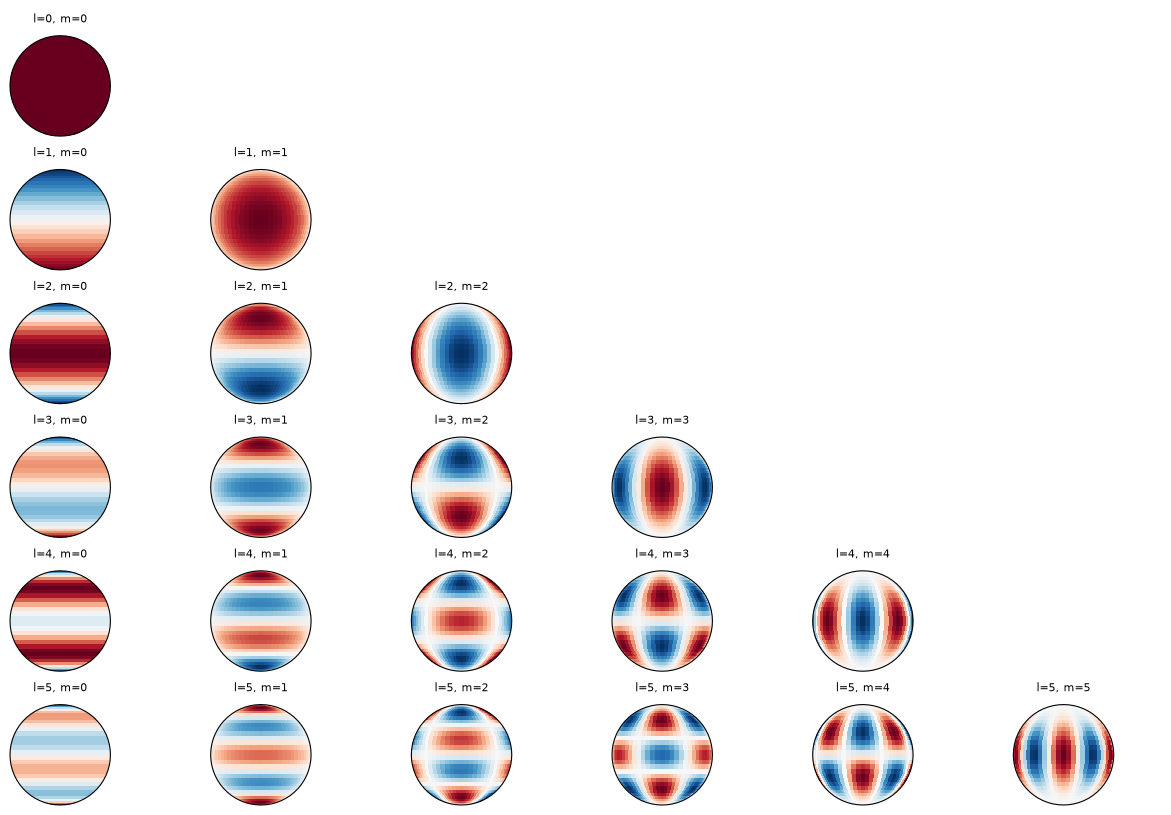

In [4]:
plt_lmax = 6

fig = plt.figure(figsize=(12, 8), layout='constrained')
subfigs = fig.subfigures(plt_lmax, plt_lmax)

for l in range(plt_lmax):
    for m in range(l+1):
        plot_sphere(vdm[midx(l,m)], fig=subfigs[l, m], projection="orthographic", title=f"l={l}, m={m}", lat=(lat - np.pi/2))

## Gramian analysis

The Gramian $G = S^T \mathrm{diag}(\omega)\, S$ captures how well the quadrature weights
preserve orthogonality of the spherical harmonics. For an exact quadrature rule, $G$ is
the identity matrix (up to a scaling factor). Any deviation indicates numerical error
in the transform.

In [5]:
gramian = torch.einsum("iqr,jqr,qr->ij", vdm, vdm, omega)

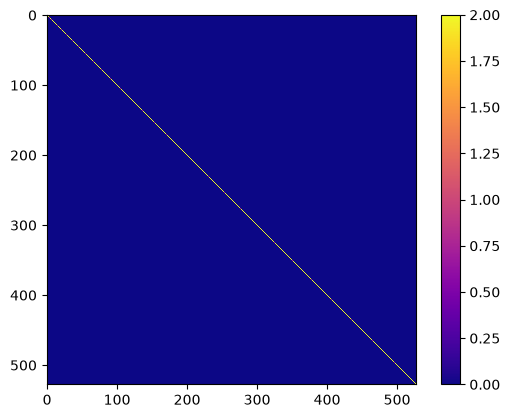

In [6]:
plt.imshow(gramian, interpolation="nearest", cmap="plasma")
plt.colorbar()

In [7]:
print(torch.max(gramian))
print(torch.argmax(gramian))
print(torch.min(gramian))
print(torch.argmin(gramian))

tensor(2.0000)
tensor(113206)
tensor(-2.2352e-07)
tensor(178452)


The condition number of $G$ tells us how much numerical error is amplified
through the analysis–synthesis cycle. A condition number close to 1 indicates
a well-conditioned transform:

In [8]:
np.linalg.cond(gramian)

np.float32(2.000001)

The diagonal entries of $G$ correspond to the norms $\|Y_l^m\|^2$ under the discrete
quadrature. A flat diagonal confirms that all modes are weighted equally:

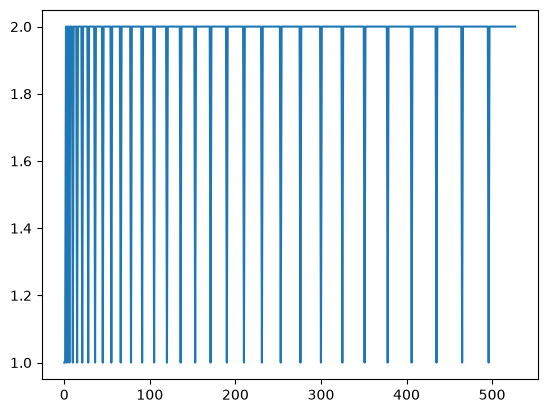

In [9]:
plt.plot(np.diag(gramian))

## Projection operator $S^{-1} S$

We can also construct the full forward ($S$) and inverse ($S^{-1}$) matrices explicitly
and examine their product. The composition $S^{-1} S$ acts as a projection operator
from grid space onto the space of band-limited functions. For a point that lies in
the column space of $S^{-1}$, the round-trip is exact.

In [10]:
# forming the Vandermonde matrix
nmodes = int(lmax * (lmax+1) / 2)

e = torch.zeros(lmax, mmax, lmax, mmax, dtype=torch.complex64)
for l in range(lmax):
    for m in range(l+1):
        e[l, m, l, m] = 1.0

Sinv = isht(e).cfloat() # l x m x nlat x nlon

e = torch.zeros(nlat, nlon, nlat, nlon, dtype=torch.float32)
for lat in range(nlat):
    for lon in range(nlon):
        e[lat, lon, lat, lon] = 1.0

S = sht(e) # nlat x nlon x l x m

In [11]:
out = torch.einsum("lmop,lmqr->lopqr", Sinv, Sinv.conj())

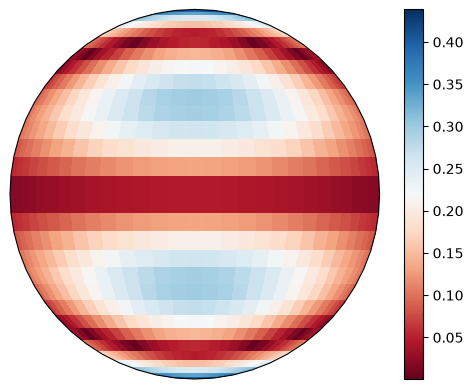

In [12]:
plot_sphere(out[3, 29, 16].abs(), projection="orthographic", colorbar=True)

The product $S^{-1} S$ should approximate an identity matrix. Let us visualize it
as a dense matrix and inspect individual slices:

In [13]:
SS = torch.einsum("lmqr, oplm->qrop", Sinv, S)

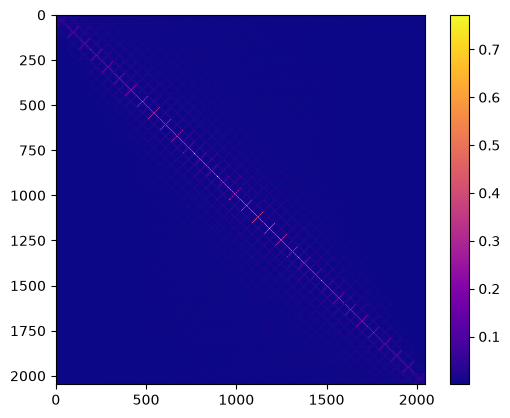

In [14]:
plt.imshow(SS.reshape(nlat*nlon, nlat*nlon).abs(), interpolation="nearest", cmap="plasma")
plt.colorbar()


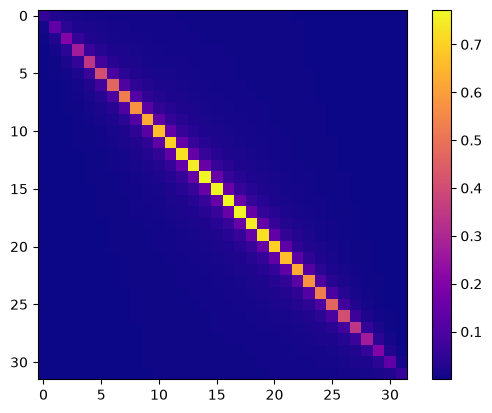

In [15]:
plt.imshow(SS[:,0,:,0].abs(), interpolation="nearest", cmap="plasma")
plt.colorbar()

## Round-trip test

As a final sanity check, we apply the SHT round-trip to a point source (delta function
on the grid). A well-conditioned transform will spread the point source into a smooth
band-limited interpolant, then reconstruct it faithfully:

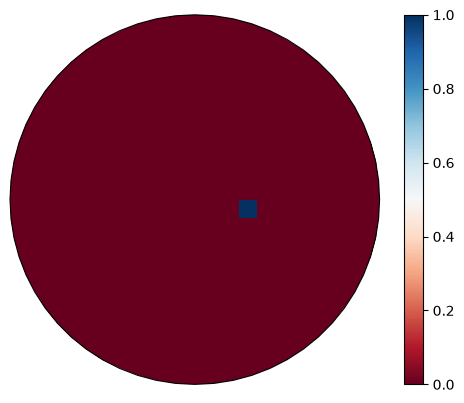

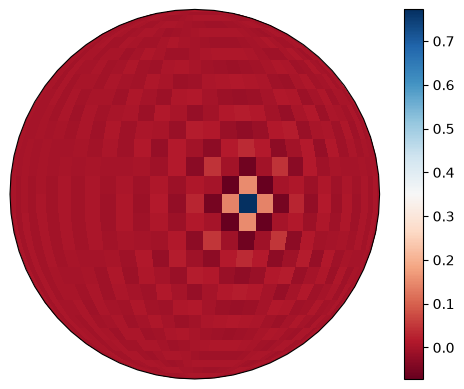

In [16]:
field = torch.zeros(nlat, nlon)
field[16,3] = 1.0

plot_sphere(field, projection="orthographic", colorbar=True)
plot_sphere(isht(sht(field)), projection="orthographic", colorbar=True)